# Download data from Climate Explorer

In [2]:
! wget https://climexp.knmi.nl/data/igiss_al_gl_a_4yrlo.dat -O data/gmst.dat
clear_output(wait = False)

In [10]:
# ! wget https://climexp.knmi.nl/dyn_links/era5_z500_daily_extended_-70--20E_-40-0N_-999-lastyear_su.nc -O data/era5_z500_daily_extended_-70--20E_-40-0N.nc
# clear_output(wait = False)

# Analogues

## Functions

In [56]:
def euclidean_distance(da, ev_date):
    
    # apply area-weighting
    weights = np.cos(np.deg2rad(da.lat))
    da_weighted = np.multiply(da, weights)

    # remove spatial mean from each day
    da_weighted = da_weighted - da_weighted.mean(["lat", "lon"])

    # squared differences
    sqdiff = np.square(da_weighted - da_weighted.sel(time = ev_date))

    # spatial sum & sqrt
    ed = np.sqrt(sqdiff.sum(["lat", "lon"])).rename("euclidean_dist")

    return ed

In [57]:
# function from Vikki's notebooks
def date_list_checks(date_list, days_apart=5):
    '''
    Takes date_list and removes:
     1) the original event (if present)
     2) any days within 5 days of another event
    '''
    import datetime
    dates = []
    for each in date_list:
        dates.append(datetime.date(int(each[:4]), int(each[4:6]), int(each[6:])))
    new_dates = dates.copy()
    for i, each in enumerate(dates): # for each date in turn
        for other in dates[i+1:]: # go through all the rest of the dates
            if other in new_dates:
                if abs((each-other).days) < days_apart:
                    new_dates.remove(other)
    new_dates_list = []
    for each in new_dates:
        new_dates_list.append(str(each.year)+str("{:02d}".format(each.month))+str("{:02d}".format(each.day)))
    return new_dates_list



def check_separation(da, sep = 5):

    # pre-processing: remove any NA values and sort by distance
    da = da.dropna(dim = "time", how = "all")
    da = da.sortby(da)

    all_dates = list(da.time.values.copy())

    # loop over analogues in ascending distance order and remove any within 5 days of each
    # doesn't actually check if part of same run (ie. could still pick up multiple days in single run of persistent low pressure)
    for i, d in enumerate(all_dates):
        for fdate in all_dates[i+1:]:
            if abs(np.timedelta64(d - fdate, "D")) < sep:
                all_dates.remove(fdate)

    all_dates = sorted(all_dates)

    # select the chosen instances
    da = da.sel(time = all_dates)
    
    # remove event (?)
    da = da.where(da != 0, drop = True)
    
    return da

In [58]:
# needs to be generalised to accept any time series & analogue field, and to manually adjust the xlim
def tplot(field, ts, d, cmap, max_sd = None, rms_quantiles = None, vmax = None):
    edist = euclidean_distance(field, d)
    corrs = xr.corr(field.sel(time = d),field, ["lat", "lon"])
    sds = field.std(["lat", "lon"])
    
    # and the colours for plotting
    if not vmax:
        ts_n = ts / ts.max()
    else: 
        ts_n = ts / vmax
    
    # set xlims
    ref_sd = sds.sel(time = d).values
    if not max_sd: 
        max_sd = np.ceil(sds.max().values / ref_sd)
    else:
        max_sd = max_sd / ref_sd
    
    # make Taylor diagram
    fig = plt.figure(figsize = (12,6), dpi= 100, facecolor='w', edgecolor='k')
    td = TaylorDiagram(ref_sd, fig = fig, rect = 111, label = d, srange = (0, max_sd), extend = True)
    
    td.add_contours(colors = "mistyrose", zorder = -9) # lines of equal RMSE
    td.add_grid(color = "papayawhip", zorder = -9)  # lines of equal correlation & SD

    if not (not rms_quantiles):
        rms = np.sqrt(ref_sd**2 + sds**2 - 2*ref_sd*sds*corrs)
        td.add_contours(colors = "darkred", levels = rms.quantile(rms_quantiles), zorder = 999, linewidths = 0.5)
    
    # much slower but allows for different colour per point
    for i in range(len(edist)):
        # if not (edist.time.dt.month[i]).isin([12,1,2]): continue
        td.add_sample(sds.values[i], corrs.values[i], color = cmap(ts_n[i]), alpha = 0.95, marker = ".", ms = 7, ls = '', zorder = ts_n[i])

## Check analogue distances

In [11]:
mslp = xr.open_dataset("data/era5_z500_daily_extended_-70--20E_-40-0N.nc").z500
ts = pd.read_csv("pr-daily_bas_mswep.csv", index_col = "time", parse_dates = ["time"]).to_xarray().precip

# filter to just the months of interest
ts = ts.sel(time = ts.time.dt.month.isin([11,12,1,2,3]))
mslp = mslp.sel(time = ts.time)

d = "2026-02-26"

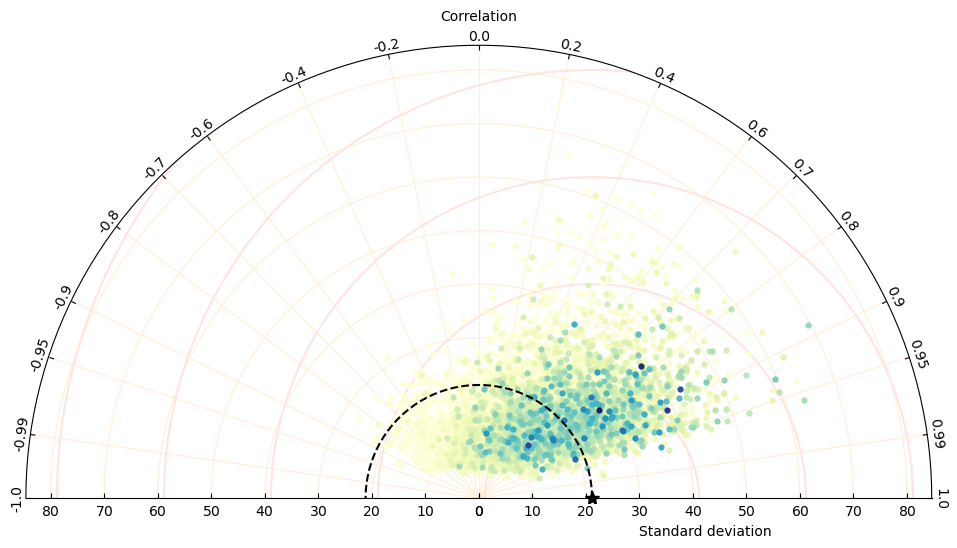

In [12]:
tplot(field = mslp.sel(lon = slice(360-60,360-30), lat = slice(-10,-30)), ts = ts, d = d, cmap = matplotlib.colormaps["YlGnBu"])

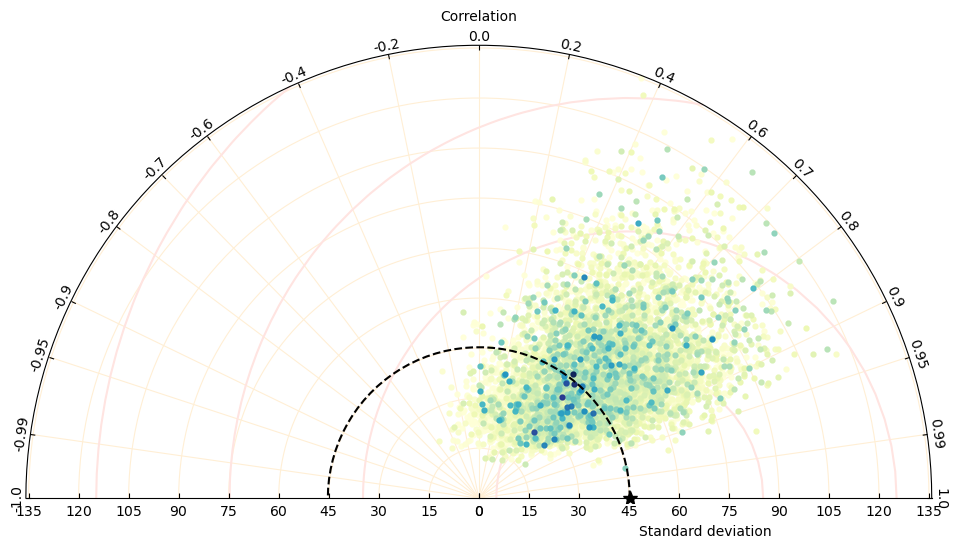

In [13]:
tplot(field = mslp, ts = ts, d = d, cmap = matplotlib.colormaps["YlGnBu"])

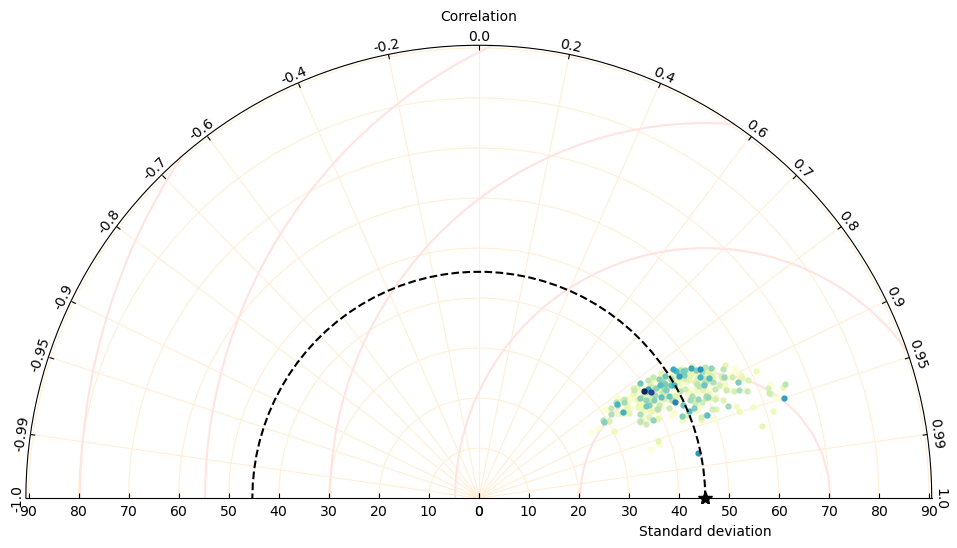

In [14]:
edist = euclidean_distance(mslp, d)

edist_q05 = edist.where(edist <= edist.quantile(0.05), drop = True)

tplot(field = mslp.sel(time = edist_q05.time), ts = ts.sel(time = edist_q05.time), d = d, cmap = matplotlib.colormaps["YlGnBu"])

/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


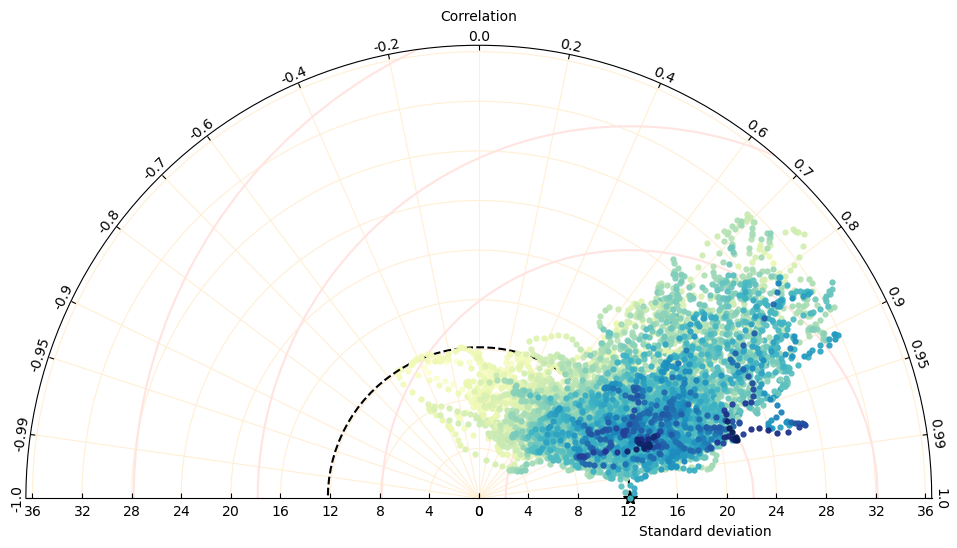

In [15]:
tplot(field = mslp.sel(lon = slice(360-60,360-30), lat = slice(-10,-30)).rolling(time = 30).mean(), ts = ts.rolling(time = 30).mean(), d = d, cmap = matplotlib.colormaps["YlGnBu"])

/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


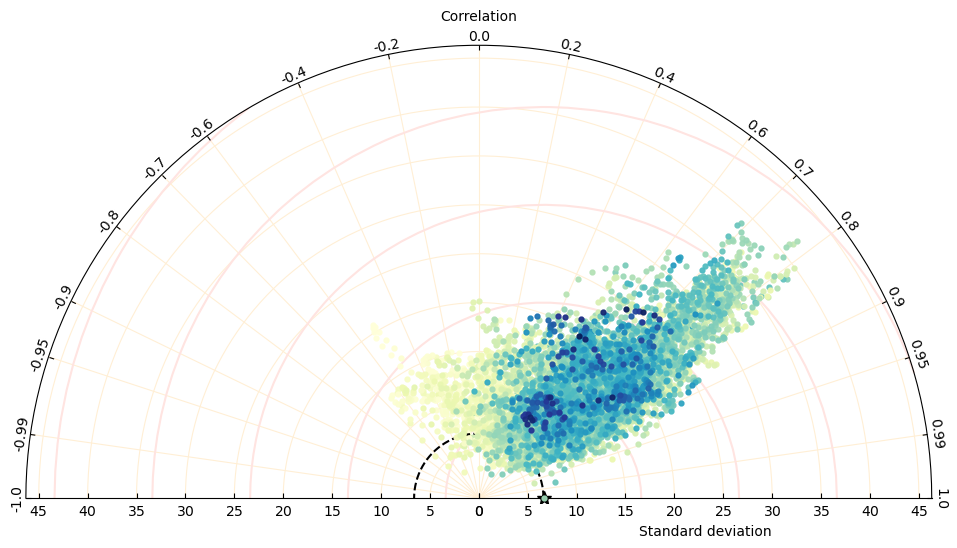

In [16]:
tplot(field = mslp.sel(lon = slice(360-60,360-30), lat = slice(-10,-30)).rolling(time = 14).mean(), ts = ts.rolling(time = 14).mean(), d = d, cmap = matplotlib.colormaps["YlGnBu"])

## Identify analogues with separation

In [17]:
mslp30 = mslp.sel(lon = slice(360-60,360-30), lat = slice(-10,-30)).rolling(time = 30).mean().dropna("time")
ts30 = ts.rolling(time = 30).sum().dropna("time")

# get all Euclidean distances
edist = euclidean_distance(mslp30, "2026-02-26")
an_q05_org = edist.where(edist <= edist.quantile(0.05)).dropna("time")
an_q05_sep = xr.concat([check_separation(an_q05_org, sep = 35), edist.sel(time = d)], "time")

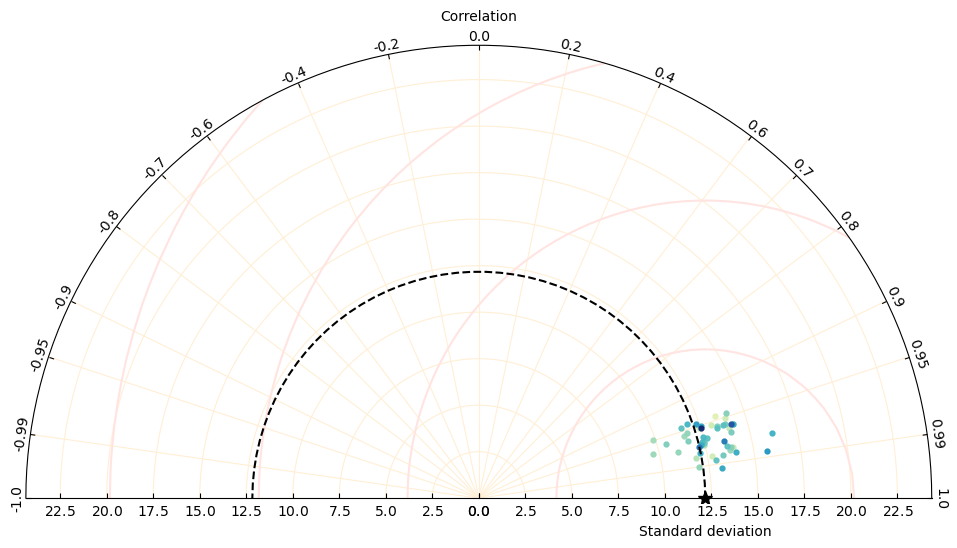

In [18]:
tplot(field = mslp30.sel(time = an_q05_sep.time), ts = ts30.sel(time = an_q05_sep.time), d = d, 
      cmap = matplotlib.colormaps["YlGnBu"], vmax = ts30.max())

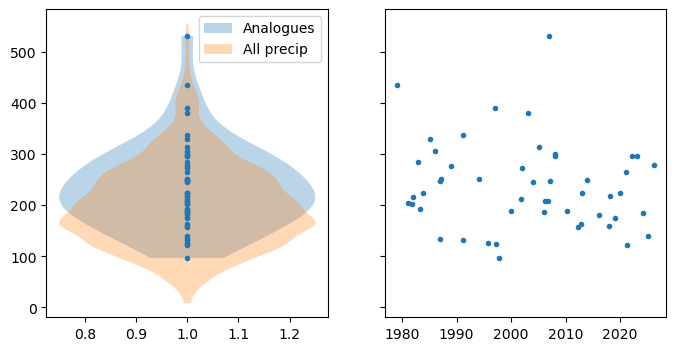

In [19]:
fig, axs = plt.subplots(ncols = 2, figsize = (8,4), dpi = 100, sharey = True)

ax = axs[0]
ax.violinplot(ts30.sel(time = an_q05_sep.time), showextrema = False)
ax.violinplot(ts30, showextrema = False)
ax.scatter(np.repeat(1, len(an_q05_sep)), ts30.sel(time = an_q05_sep.time), marker = ".")

ax.legend(["Analogues", "All precip"])

ax = axs[1]
ax.plot(an_q05_sep.time, ts30.sel(time = an_q05_sep.time), marker = ".", ls = "")

## Violinplots

Text(0.5, 1.0, 'Precipitation (mm)')

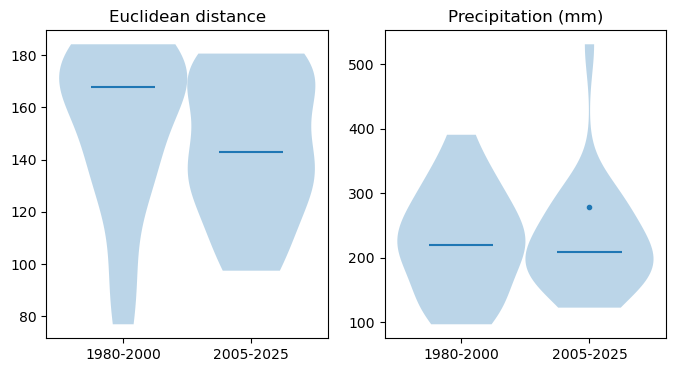

In [73]:
fig, axs = plt.subplots(ncols = 2, figsize = (8,4), dpi = 100, sharey = False)

ax = axs[0]
ed_split = [an_q05_sep.sel(time = slice("1980-05", "2000-05")),
            an_q05_sep.sel(time = slice("2005-05", "2025-05"))]
ax.violinplot(ed_split, positions = [0.5, 1], showextrema = False, showmedians = True, showmeans = False)
ax.set_xticks([0.5,1]); ax.set_xticklabels(["1980-2000","2005-2025"])
ax.set_title("Euclidean distance")


ax = axs[1]
pr_split = [ts30.sel(time = an_q05_sep.sel(time = slice("1980-05", "2000-05")).time),
            ts30.sel(time = an_q05_sep.sel(time = slice("2005-05", "2025-05")).time)]
ax.violinplot(pr_split, positions = [0.5, 1], showextrema = False, showmedians = True, showmeans = False)
ax.plot(1, ts30.sel(time = "2026-02-26"), marker = ".", color = "tab:blue")

ax.set_xticks([0.5,1]); ax.set_xticklabels(["1980-2000","2005-2025"])
ax.set_title("Precipitation (mm)")

In [77]:
ed_split20 = [da.sortby(da).isel(time = slice(None, 20)) for da in ed_split]
pr_split20 = [ts30.sel(time = da.time) for da in ed_split20]

Text(0.5, 1.0, 'Precipitation (mm)')

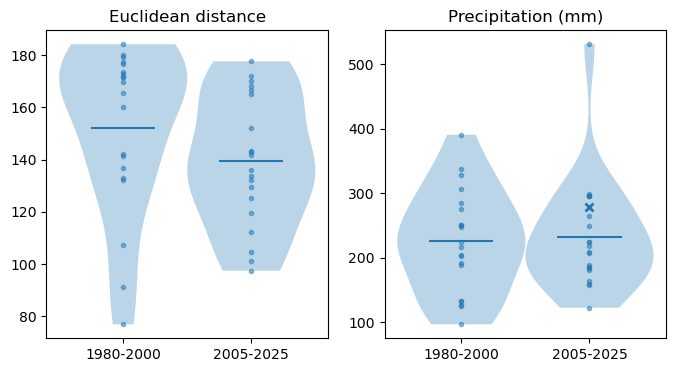

In [78]:
fig, axs = plt.subplots(ncols = 2, figsize = (8,4), dpi = 100, sharey = False)

ax = axs[0]
ax.violinplot(ed_split20, positions = [0.5, 1], showextrema = False, showmedians = False, showmeans = True)
ax.scatter(np.repeat(0.5,20), ed_split20[0].values, marker = ".", alpha = 0.5, color = "tab:blue")
ax.scatter(np.repeat(1,20), ed_split20[1].values, marker = ".", alpha = 0.5, color = "tab:blue")
ax.set_xticks([0.5,1]); ax.set_xticklabels(["1980-2000","2005-2025"])
ax.set_title("Euclidean distance")


ax = axs[1]
ax.violinplot(pr_split20, positions = [0.5, 1], showextrema = False, showmedians = False, showmeans = True)
ax.scatter(np.repeat(0.5,20), pr_split20[0].values, marker = ".", alpha = 0.5, color = "tab:blue")
ax.scatter(np.repeat(1,20), pr_split20[1].values, marker = ".", alpha = 0.5, color = "tab:blue")
ax.plot(1, ts30.sel(time = "2026-02-26"), marker = "x", color = "tab:blue", mew = 2)

ax.set_xticks([0.5,1]); ax.set_xticklabels(["1980-2000","2005-2025"])
ax.set_title("Precipitation (mm)")

## Stampplots

/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


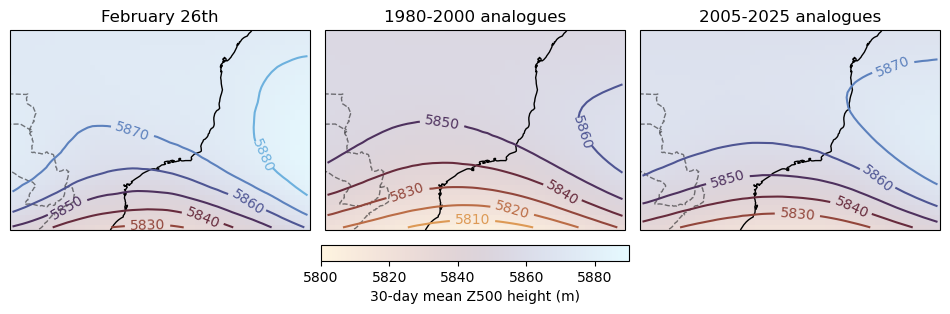

In [109]:
fig, axs = plt.subplots(ncols = 3, figsize = (12,4), dpi = 100, sharey = False, subplot_kw = {"projection" : mapproj})
plt.subplots_adjust(wspace = 0.05)

da_ev = mslp30.sel(time = "2026-02-26")
comp_past = mslp30.sel(time = ed_split20[0].time).mean("time")
comp_present = cbar = mslp30.sel(time = ed_split20[1].time).mean("time")
step = 10
vmin = np.floor(min(da_ev.min(), comp_past.min(), comp_present.min())/step) * step
vmax = np.ceil(max(da_ev.max(), comp_past.max(), comp_present.max())/step) * step

plot_kwargs = {"cmap" : "managua", "vmin" : vmin, "vmax" : vmax}

for i in range(3):
    ax = axs[i]
    z = [da_ev, comp_past, comp_present][i]
    cbar = z.plot(ax = ax, **plot_kwargs, alpha = 0.2, add_colorbar = False)
    cs = ax.contour(z.lon, z.lat, z, levels = np.arange(vmin, vmax, step), **plot_kwargs)
    plt.clabel(cs)
    ax.set_title(["February 26th", "1980-2000 analogues", "2005-2025 analogues"][i])

    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS, color = "k", alpha = 0.5, ls = "--")

plt.colorbar(cbar, ax = axs, location = "bottom", label = "30-day mean Z500 height (m)", fraction = 0.05, pad = 0.05)
plt.savefig("fig/z500-composites.png")

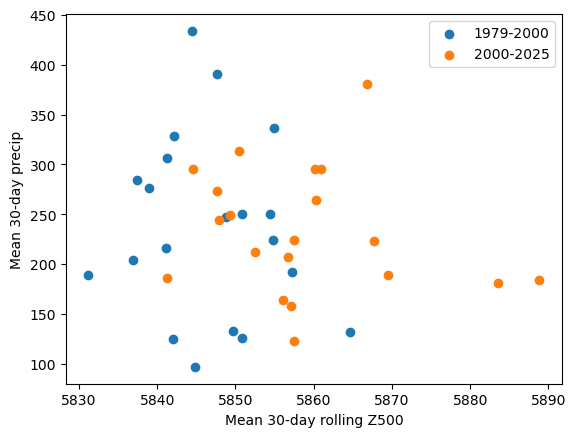

In [24]:
plt.scatter(mslp30.sel(time = ed_split20[0].time).mean(["lat", "lon"]), pr_split20[0], label = "1979-2000")
plt.scatter(mslp30.sel(time = ed_split20[1].time).mean(["lat", "lon"]), pr_split20[1], label = "2000-2025")
plt.xlabel("Mean 30-day rolling Z500")
plt.ylabel("Mean 30-day precip")

plt.legend()

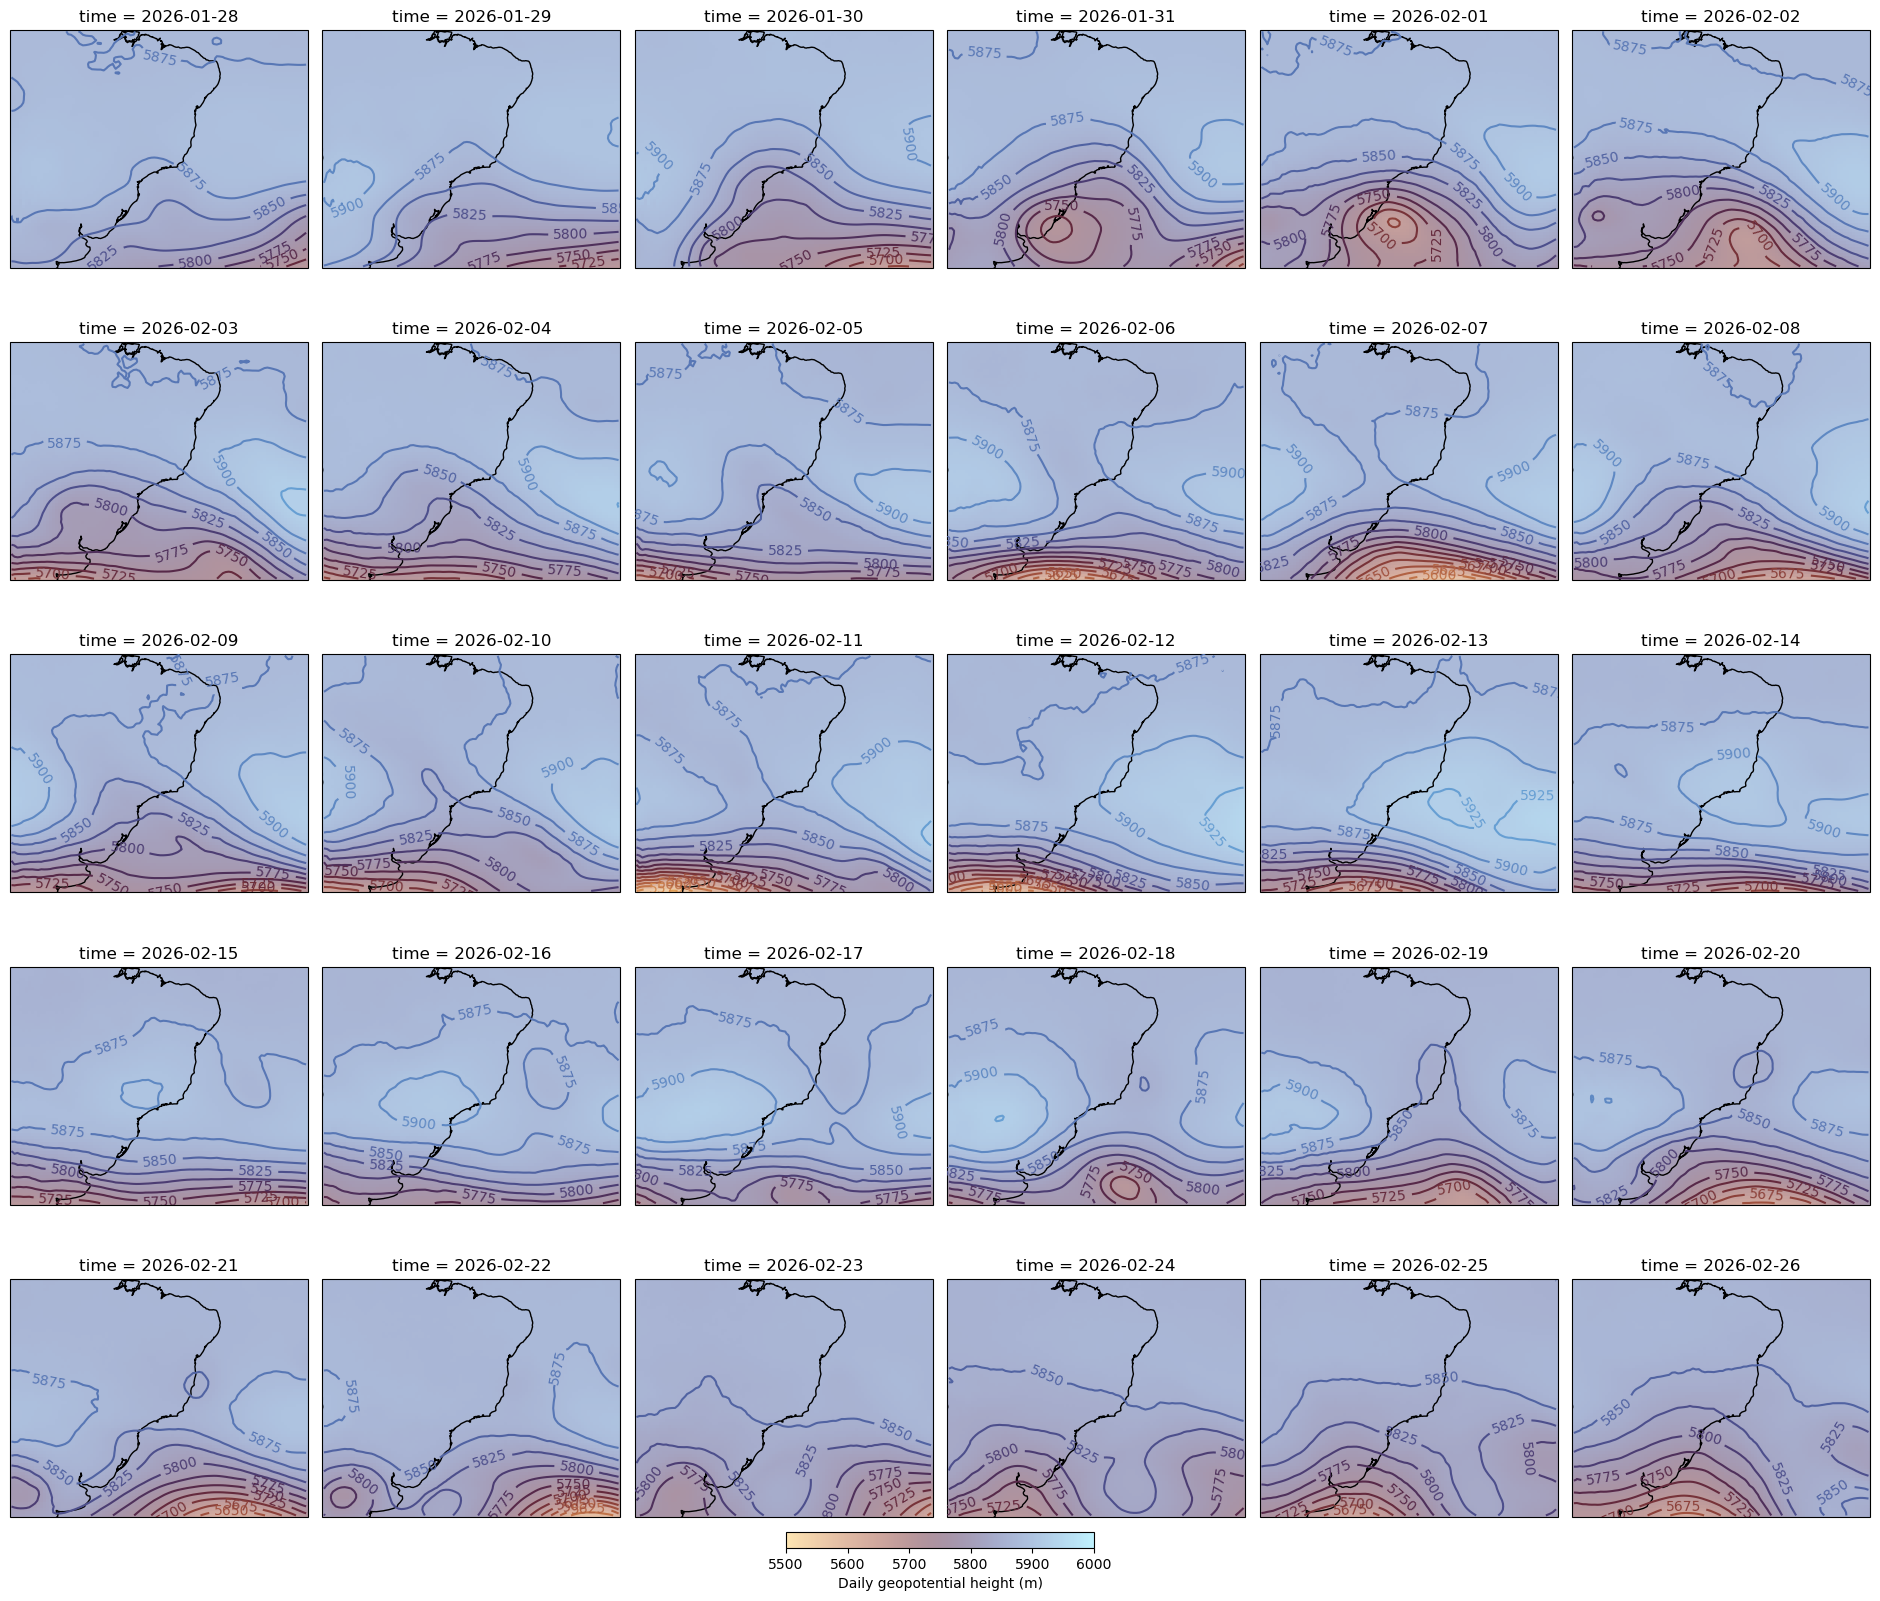

In [101]:
nc = 6; nr = 5

fig, axs = plt.subplots(ncols = nc, nrows = nr, figsize = (nc*4, nr*4), dpi = 100, subplot_kw = {"projection" : mapproj})
plt.subplots_adjust(wspace = 0.05)

d = "20260226"
# d = ed_split20[0][0].time.dt.strftime("%Y%m%d").values
# d = ed_split20[1][0].time.dt.strftime("%Y%m%d").values

da = mslp.sel(time = slice(None, d)).isel(time = slice(-30,None))
step = 25
vmin = np.floor(da.min()/step) * step
vmax = np.ceil(da.max()/step) * step


plot_kwargs = {"cmap" : "managua", "vmin" : 5500, "vmax" : 6000}

for i in range(30):
    ax = axs.flatten()[i]
    cbar = da.isel(time = i).plot(ax = ax, alpha = 0.5, add_colorbar = False, **plot_kwargs)
    cs = ax.contour(da.lon, da.lat, da.isel(time = i), levels = np.arange(vmin, vmax, step), **plot_kwargs)
    plt.clabel(cs)
    ax.coastlines()

plt.colorbar(cbar, ax = axs, location = "bottom", fraction = 0.01, pad = 0.01, label = "Daily geopotential height (m)")

plt.savefig("fig/z500-stampplots_"+str(d)+".png")